# Polar Twist Posterior with mTPCN

Replicate the polar-twist workflow using the multiple-try pCN sampler.

In [2]:
import os
import sys
from pathlib import Path
import time
import json

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'pyproject.toml').exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_path = repo_root / 'src'
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from multiproposal.algorithms.mpcn import mpcn_step, mpcn_chain
from multiproposal.algorithms.mtpcn import mtpcn_step, mtpcn_chain
from multiproposal.algorithms.mess import mess_step
from multiproposal.algorithms.effective_sample_size import estimate_effective_sample_size
from multiproposal.problems.toy_custom_likelihood import ToyCustomLikelihood2D
from multiproposal.plotting.diagnostics import make_hist_grid_comps
from multiproposal.utils.run_paths import build_run_dirs, format_float_tag
from reports.figure_style import apply_pub_style

In [3]:
def f_polar_twist(x, alpha, weight_x=1.0, weight_y=1.0):
    x1, x2 = x
    radius = np.sqrt(x1 ** 2 + x2 ** 2)
    comp1 = x1 * np.cos(alpha * weight_x * radius) - x2 * np.sin(alpha * weight_y * radius)
    comp2 = x1 * np.sin(alpha * weight_x * radius) + x2 * np.cos(alpha * weight_y * radius)
    return np.array([comp1, comp2])

def log_likelihood_polar_twist(x, y_obs, sigma=0.3, alpha=0.5, weight_x=1.0, weight_y=1.0):
    r = f_polar_twist(x, alpha=alpha, weight_x=weight_x, weight_y=weight_y) - y_obs
    return -0.5 * np.dot(r, r) / (sigma ** 2)

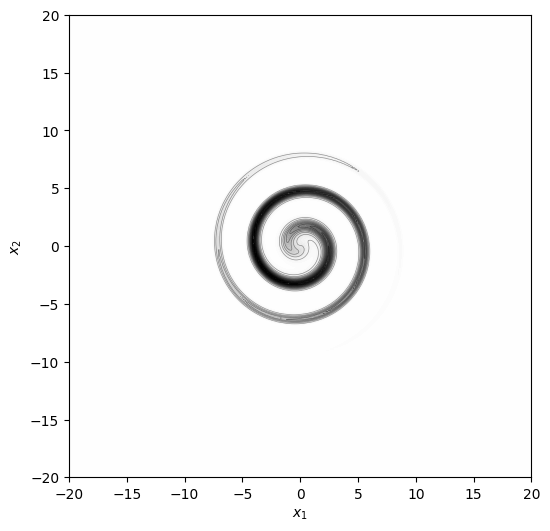

In [4]:
# Publication-quality likelihood contours (polar twist)
data_seed = 202
rng = np.random.default_rng(data_seed)
# alpha = 0.4
# sigma_noise = 3.0
# prior_std = 3
# prior_cov = prior_std ** 2 * np.array([[1.0, 0.3], [0.3, 1]])
# prior_mean = np.zeros(2)
# weight_x = 0.3
# weight_y = 4

# Example used in the paper
alpha = 2
sigma_noise = 2.0
prior_std = 2.0
prior_cov = prior_std ** 2 * np.array([[1.0, 0.3], [0.3, 0.5]])
prior_mean = np.zeros(2)
weight_x = 1
weight_y = 1


prior_sample = rng.multivariate_normal(prior_mean, prior_cov)
theta_true = f_polar_twist(prior_sample, alpha=alpha, weight_x=weight_x, weight_y=weight_y)
y_obs = theta_true + rng.normal(0.0, sigma_noise, size=theta_true.shape)

grid_min = -20.0
grid_max = 20.0
grid_n = 300
grid = np.linspace(grid_min, grid_max, grid_n)
X1, X2 = np.meshgrid(grid, grid)
log_like = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x_grid = np.array([X1[i, j], X2[i, j]])
        log_like[i, j] = log_likelihood_polar_twist(x_grid, y_obs, sigma=sigma_noise, alpha=alpha, weight_x=weight_x, weight_y=weight_y)
log_like -= log_like.max()
like = np.exp(log_like)

fig, ax = plt.subplots(1, 1, figsize=(6.5, 5.2), constrained_layout=True)
levels_fill = 50
levels_line = 14
ax.contourf(X1, X2, like, levels=levels_fill, cmap="Grays", alpha=0.9)
ax.contour(X1, X2, like, levels=levels_line, colors="black", linewidths=0.5, alpha=0.4)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
# ax.set_title("Polar twist likelihood contours")

plt.show()

## Posterior formulation (polar twist)

Let $x = (x_1, x_2)^T \in \mathbb{R}^2$ and $r = \sqrt{x_1^2 + x_2^2}$. The forward map defined in the code is

$$
f(x;\alpha) = \begin{bmatrix}
x_1 \cos(\alpha r) - x_2 \sin(\alpha r) \\
x_1 \sin(\alpha r) + x_2 \cos(\alpha r)
\end{bmatrix}.
$$

The data are generated as

$$
x_{\text{true}} \sim \mathcal{N}(\mu, C), \quad y_{\text{obs}} = f(x_{\text{true}};\alpha) + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I_2),
$$

with $\mu = (0,0)^T$, $C = \text{prior\_std}^2 \begin{bmatrix}1 & 0.3 \\ 0.3 & 0.5\end{bmatrix}$ and $\text{prior\_std}=2.0$ (so $C = 4\begin{bmatrix}1 & 0.3 \\ 0.3 & 0.5\end{bmatrix}$), $\sigma = \text{sigma\_noise}=2.0$, and $\alpha = 2.0$ in this notebook.

The Gaussian likelihood implied by `log_likelihood_polar_twist` is

$$
p(y_{\text{obs}}\mid x) = (2\pi\sigma^2)^{-1}
\exp\left(-\frac{1}{2\sigma^2}\left\|f(x;\alpha)-y_{\text{obs}}\right\|^2\right).
$$

The prior density is

$$
p(x) = (2\pi)^{-1} |C|^{-1/2}
\exp\left(-\frac{1}{2}(x-\mu)^T C^{-1} (x-\mu)\right).
$$

Therefore the posterior is

$$
p(x\mid y_{\text{obs}}) \propto
\exp\left(-\frac{1}{2\sigma^2}\left\|f(x;\alpha)-y_{\text{obs}}\right\|^2
-\frac{1}{2}(x-\mu)^T C^{-1} (x-\mu)\right).
$$

Equivalently, the log-posterior (up to an additive constant) is

$$
\log p(x\mid y_{\text{obs}}) =
-\frac{1}{2\sigma^2}\left\|f(x;\alpha)-y_{\text{obs}}\right\|^2
-\frac{1}{2}(x-\mu)^T C^{-1} (x-\mu) + \text{const}.
$$

In [5]:
# # Match the data-generation pattern from the sweep notebook
# alpha = 0.4
# sigma_noise = 3.0
# prior_std = 3
# prior_cov = prior_std ** 2 * np.array([[1.0, 0.3], [0.3, 1]])
# prior_mean = np.zeros(2)
# weight_x = 0.3
# weight_y = 4

# Example used in the paper
alpha = 2
sigma_noise = 1.0
prior_std = 2.0
prior_cov = prior_std ** 2 * np.array([[1.0, 0.3], [0.3, 0.5]])
prior_mean = np.zeros(2)
weight_x = 1
weight_y = 1


data_seed = 202
rng = np.random.default_rng(data_seed)
prior_sample = rng.multivariate_normal(prior_mean, prior_cov)
theta_true = f_polar_twist(prior_sample, alpha=alpha, weight_x=weight_x, weight_y=weight_y)
y_obs = theta_true + rng.normal(0.0, sigma_noise, size=theta_true.shape)

def log_likelihood(x):
    return log_likelihood_polar_twist(
        x,
        y_obs,
        sigma=sigma_noise,
        alpha=alpha,
        weight_x=weight_x,
        weight_y=weight_y,
    )

problem = ToyCustomLikelihood2D(
    log_likelihood_fn=log_likelihood,
    prior_mean=prior_mean,
    prior_cov=prior_cov,
 )

data_config = {
    'model': 'polar_twist',
    'alpha': alpha,
    'weight_x': weight_x,
    'weight_y': weight_y,
    'sigma_noise': sigma_noise,
    'prior_std': prior_std,
    'prior_cov': prior_cov.tolist(),
    'prior_mean': prior_mean.tolist(),
    'data_seed': data_seed,
}

print('y_obs:', y_obs)
print('True x:', prior_sample)
print('Log-posterior at prior mean:', problem.log_posterior(prior_mean))

y_obs: [ 1.59110063 -3.32997972]
True x: [-3.13349585 -2.43303473]
Log-posterior at prior mean: -6.810183087048239


In [6]:
# MCMC configuration
n_iters = 200000
rho = 0.1
n_props = 10
mess_M = 10
run_mess = True  # Toggle MESS run + plots
seed_mcmc = 202
rng_init = np.random.default_rng(seed_mcmc)
x0 = problem.sample_prior(rng_init)
rng_mtpcn = np.random.default_rng(seed_mcmc)
rng_mpcn = np.random.default_rng(seed_mcmc)
rng_mess = np.random.default_rng(seed_mcmc)

algo_config = {
    'n_iters': n_iters,
    'rho': rho,
    'n_props': n_props,
    'mess_M': mess_M,
    'run_mess': run_mess,
    'seed_mcmc': seed_mcmc,
}
sigma_tag = format_float_tag(sigma_noise, precision=2)
prior_tag = format_float_tag(prior_std, precision=2)
alpha_tag = format_float_tag(alpha, precision=2)
weight_x_tag = format_float_tag(weight_x, precision=2)
weight_y_tag = format_float_tag(weight_y, precision=2)
rho_tag = format_float_tag(rho, precision=5)
tag_parts = [
    f'P{n_props}',
    f'rho{rho_tag}',
    f'iters{n_iters}',
    f'seed{seed_mcmc}',
    f'sigma{sigma_tag}',
    f'prior{prior_tag}',
    f'alpha{alpha_tag}',
    f'wx{weight_x_tag}',
    f'wy{weight_y_tag}',
]

mtpcn_estimations_dir, mtpcn_reports_dir, mtpcn_run_name, mtpcn_run_config = build_run_dirs(
    repo_root,
    dataset='polar_twist',
    algorithm='mtpcn',
    data_config=data_config,
    algorithm_config=algo_config,
    algorithm_dir='',
    tag_parts=tag_parts,
 )
mpcn_estimations_dir, mpcn_reports_dir, mpcn_run_name, mpcn_run_config = build_run_dirs(
    repo_root,
    dataset='polar_twist',
    algorithm='mpcn',
    data_config=data_config,
    algorithm_config=algo_config,
    algorithm_dir='',
    tag_parts=tag_parts,
 )
reports_dir = mtpcn_reports_dir

mtpcn_samples_path = mtpcn_estimations_dir / f"mtpcn_P{n_props}_rho{rho_tag}_seed{seed_mcmc}.npz"
mtpcn_metrics_path = mtpcn_estimations_dir / f"mtpcn_P{n_props}_rho{rho_tag}_seed{seed_mcmc}_metrics.json"
mpcn_samples_path = mpcn_estimations_dir / f"mpcn_P{n_props}_rho{rho_tag}_seed{seed_mcmc}.npz"
mpcn_metrics_path = mpcn_estimations_dir / f"mpcn_P{n_props}_rho{rho_tag}_seed{seed_mcmc}_metrics.json"
mess_samples_path = mtpcn_estimations_dir / f"mess_uniform_M{mess_M}_seed{seed_mcmc}.npz"
mess_metrics_path = mtpcn_estimations_dir / f"mess_uniform_M{mess_M}_seed{seed_mcmc}_metrics.json"

def save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec):
    payload = dict(metrics)
    payload['accept_rate'] = None if accept_rate is None else float(accept_rate)
    payload['runtime_sec'] = float(runtime_sec)
    with open(metrics_path, 'w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2)

def load_metrics_json(metrics_path):
    if not metrics_path.exists():
        return None
    with open(metrics_path, 'r', encoding='utf-8') as handle:
        return json.load(handle)

def save_chain_bundle(samples_path, metrics_path, chain, accept_rate, runtime_sec, metrics=None):
    accept_val = np.nan if accept_rate is None else float(accept_rate)
    np.savez_compressed(
        samples_path,
        chain=chain,
        accept_rate=accept_val,
        runtime_sec=float(runtime_sec),
    )
    if metrics is not None:
        save_metrics_json(metrics_path, metrics, accept_rate, runtime_sec)

def load_chain_bundle(samples_path, metrics_path):
    if not samples_path.exists():
        return None
    data = np.load(samples_path, allow_pickle=False)
    chain = data['chain']
    accept_rate = float(data['accept_rate']) if 'accept_rate' in data else np.nan
    if np.isnan(accept_rate):
        accept_rate = None
    runtime_sec = float(data['runtime_sec']) if 'runtime_sec' in data else 0.0
    metrics = load_metrics_json(metrics_path)
    return chain, accept_rate, runtime_sec, metrics

# mTPCN chain (cached)
mtpcn_loaded = load_chain_bundle(mtpcn_samples_path, mtpcn_metrics_path)
if mtpcn_loaded is not None:
    chain_mtpcn, accept_rate_mtpcn, runtime_mtpcn_sec, metrics_mtpcn = mtpcn_loaded
    accept_display = np.nan if accept_rate_mtpcn is None else accept_rate_mtpcn
    print(
        f"mTPCN loaded: P={n_props}, rho={rho:.3f}, accept={accept_display:.3f}, "
        f"runtime={runtime_mtpcn_sec:.2f}s"
    )
else:
    t0 = time.perf_counter()
    chain_mtpcn, accept_rate_mtpcn = mtpcn_chain(
        x0,
        problem,
        rng_mtpcn,
        n_iters,
        rho=rho,
        n_props=n_props,
    )
    runtime_mtpcn_sec = time.perf_counter() - t0
    save_chain_bundle(mtpcn_samples_path, mtpcn_metrics_path, chain_mtpcn, accept_rate_mtpcn, runtime_mtpcn_sec)
    print(
        f"mTPCN done: P={n_props}, rho={rho:.3f}, accept={accept_rate_mtpcn:.3f}, "
        f"runtime={runtime_mtpcn_sec:.2f}s"
    )

# mPCN chain (cached)
mpcn_loaded = load_chain_bundle(mpcn_samples_path, mpcn_metrics_path)
if mpcn_loaded is not None:
    chain_mpcn, accept_rate_mpcn, runtime_mpcn_sec, metrics_mpcn = mpcn_loaded
    accept_display = np.nan if accept_rate_mpcn is None else accept_rate_mpcn
    print(
        f"mPCN loaded: P={n_props}, rho={rho:.3f}, accept={accept_display:.3f}, "
        f"runtime={runtime_mpcn_sec:.2f}s"
    )
else:
    t0 = time.perf_counter()
    chain_mpcn, accepted_index_mpcn = mpcn_chain(
        x0,
        problem,
        rng_mpcn,
        n_iters,
        rho=rho,
        n_props=n_props,
        return_indices=True,
    )
    runtime_mpcn_sec = time.perf_counter() - t0
    accept_rate_mpcn = float(np.mean(accepted_index_mpcn != 0))
    save_chain_bundle(mpcn_samples_path, mpcn_metrics_path, chain_mpcn, accept_rate_mpcn, runtime_mpcn_sec)
    print(
        f"mPCN done: P={n_props}, rho={rho:.3f}, accept={accept_rate_mpcn:.3f}, "
        f"runtime={runtime_mpcn_sec:.2f}s"
    )

# MESS chain (cached)
chain_mess = None
runtime_mess_sec = 0.0
metrics_mess = None
if run_mess:
    mess_loaded = load_chain_bundle(mess_samples_path, mess_metrics_path)
    if mess_loaded is not None:
        chain_mess, _, runtime_mess_sec, metrics_mess = mess_loaded
        print(f"MESS loaded: M={mess_M}, runtime={runtime_mess_sec:.2f}s")
    else:
        chain_mess = np.zeros((n_iters + 1, problem.dim), dtype=float)
        chain_mess[0] = x0
        x = x0.copy()
        t0 = time.perf_counter()
        for t in range(n_iters):
            x, _, _ = mess_step(
                x,
                problem,
                rng_mess,
                M=mess_M,
                use_lp=False,
                distance_metric='angular',
                lam=0.0,
            )
            chain_mess[t + 1] = x
        runtime_mess_sec = time.perf_counter() - t0
        save_chain_bundle(mess_samples_path, mess_metrics_path, chain_mess, None, runtime_mess_sec)
        print(f"MESS done: M={mess_M}, runtime={runtime_mess_sec:.2f}s")
else:
    print('MESS disabled (run_mess=False).')

mTPCN loaded: P=10, rho=0.100, accept=0.498, runtime=13.74s
mPCN loaded: P=10, rho=0.100, accept=0.458, runtime=7.72s
MESS loaded: M=10, runtime=9.26s


In [ ]:
# # Publication-quality likelihood contours (polar twist)
# apply_pub_style()
# reports_dir.mkdir(parents=True, exist_ok=True)

# grid_min = -20.0
# grid_max = 20.0
# grid_n = 300
# grid = np.linspace(grid_min, grid_max, grid_n)
# X1, X2 = np.meshgrid(grid, grid)
# log_like = np.zeros_like(X1)
# for i in range(X1.shape[0]):
#     for j in range(X1.shape[1]):
#         x_grid = np.array([X1[i, j], X2[i, j]])
#         log_like[i, j] = log_likelihood_polar_twist(
#             x_grid,
#             y_obs,
#             sigma=sigma_noise,
#             alpha=alpha,
#             weight_x=weight_x,
#             weight_y=weight_y,
#         )
# log_like -= log_like.max()
# like = np.exp(log_like)

# fig, ax = plt.subplots(1, 1, figsize=(6.5, 5.2), constrained_layout=True)
# levels_fill = 50
# levels_line = 14
# ax.contourf(X1, X2, like, levels=levels_fill, cmap="Grays", alpha=0.9)
# ax.contour(X1, X2, like, levels=levels_line, colors="black", linewidths=0.5, alpha=0.4)
# ax.set_aspect("equal", adjustable="box")
# ax.set_xlabel(r"$x_1$")
# ax.set_ylabel(r"$x_2$")
# # ax.set_title("Polar twist likelihood contours")

# def _fmt(val):
#     return str(val).replace(".", "p")

# config_tag = (
#     f"alpha{_fmt(alpha)}_sigma{_fmt(sigma_noise)}_prior{_fmt(prior_std)}_"
#     f"wx{_fmt(weight_x)}_wy{_fmt(weight_y)}_grid{grid_n}_seed{seed_mcmc}"
#  )
# fig_path = reports_dir / f"likelihood_contours_polar_twist_{config_tag}.png"
# fig.savefig(fig_path, bbox_inches="tight")
# print(f"Saved {fig_path}")
# plt.show()

In [ ]:
# Proposal illustrations for selected iterations (separate diagnostic run)
plot_iters = [nr for nr in np.arange(9010, 9020, 1)]
plot_iters = sorted(set(plot_iters))
n_iters_diag = max(plot_iters) + 1
seed_mtpcn_diag = 202
seed_mpcn_diag = 202
rng_diag = np.random.default_rng(seed_mtpcn_diag)
rng_mpcn_diag = np.random.default_rng(seed_mpcn_diag)
x0_diag = x0.copy()

grid_min = -7.0
grid_max = 7.0
grid = np.linspace(grid_min, grid_max, 300)
X1, X2 = np.meshgrid(grid, grid)
log_like = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x_grid = np.array([X1[i, j], X2[i, j]])
        log_like[i, j] = log_likelihood_polar_twist(
            x_grid,
            y_obs,
            sigma=sigma_noise,
            alpha=alpha,
            weight_x=weight_x,
            weight_y=weight_y,
        )
log_like -= log_like.max()
like_density = np.exp(log_like)

levels_fill = 50
levels_line = 14
theta = np.linspace(0.0, 2.0 * np.pi, 800)

def plot_mtpcn_snapshot(ax, snapshot, iter_idx, show_idx_info=False):
    mauve = "#C27BA0"
    x = snapshot["x"]
    props = snapshot["props"]
    back_props = snapshot["back_props"]
    y_star = snapshot["y_star"]
    accepted = snapshot["accepted"]
    idx = snapshot["idx"]
    idx_is_max = snapshot["idx_is_max"]
    accepted_point = y_star if accepted else x
    ax.contourf(X1, X2, like_density, levels=levels_fill, cmap='Greys', alpha=0.35)
    ax.contour(X1, X2, like_density, levels=levels_line, colors='black', linewidths=0.5, alpha=0.2)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.grid(False)
    ax.scatter(props[:, 0], props[:, 1], color='teal', s=12, alpha=0.8, label='forward props', zorder=2)
    ax.scatter(back_props[:, 0], back_props[:, 1], color=mauve, s=12, alpha=0.8, label='reverse props', zorder=2)
    ax.scatter([x[0]], [x[1]], color='green', s=110, marker='o', label='current', zorder=3)
    ax.scatter([y_star[0]], [y_star[1]], color='teal', s=110, marker='*', label='selected', zorder=4)
    ax.scatter([accepted_point[0]], [accepted_point[1]], facecolors='none', edgecolors='green',
               s=160, marker='s', linewidths=2.0, label='accepted', zorder=5)
    if show_idx_info:
        ax.text(
            0.02,
            0.98,
            f'idx: {idx}\nidx==argmax: {idx_is_max}',
            transform=ax.transAxes,
            va='top',
            ha='left',
            fontsize=9,
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
        )
    ax.set_title(f'Iter={iter_idx}')

def plot_mpcn_snapshot(ax, snapshot, iter_idx, show_center_panel=False, show_ellipse=False):
    mu = problem.prior_mean()
    x = snapshot["x"]
    x_center = snapshot["x_center"]
    nu_c = snapshot["nu_c"]
    props = snapshot["props"]
    candidates = snapshot["candidates"]
    accepted_idx = snapshot["accepted_idx"]
    ellipse = mu + np.cos(theta)[:, None] * (x - mu) + np.sin(theta)[:, None] * nu_c
    if show_center_panel:
        ax0, ax1 = ax
        for sub_ax in (ax0, ax1):
            sub_ax.contourf(X1, X2, like_density, levels=levels_fill, cmap='Greys', alpha=0.35)
            sub_ax.contour(X1, X2, like_density, levels=levels_line, colors='black', linewidths=0.5, alpha=0.2)
            sub_ax.set_aspect('equal', adjustable='box')
            sub_ax.set_xlabel('x1')
            sub_ax.set_ylabel('x2')
            sub_ax.grid(False)
        if show_ellipse:
            ax0.plot(ellipse[:, 0], ellipse[:, 1], color='black', linewidth=1.5, zorder=2)
        ax0.scatter([x[0]], [x[1]], color='green', s=110, marker='o', label='current', zorder=3)
        ax0.scatter([x_center[0]], [x_center[1]], color='tab:orange', s=80, marker='o', label='center', zorder=3)
        ax0.set_title(f'Iter={iter_idx}')

        ax1.scatter([x[0]], [x[1]], color='green', s=110, marker='o', label='current', zorder=3)
        ax1.scatter([x_center[0]], [x_center[1]], color='tab:orange', s=80, marker='o', label='center', zorder=3)
        ax1.scatter(props[:, 0], props[:, 1], color='teal', s=10, alpha=0.8, label='props', zorder=2)
        accepted_point = candidates[accepted_idx]
        ax1.scatter([accepted_point[0]], [accepted_point[1]], facecolors='none', edgecolors='green',
                    s=160, marker='s', linewidths=2.0, label='accepted', zorder=4)
        ax1.set_title(f'Iter={iter_idx}')
        return

    ax.contourf(X1, X2, like_density, levels=levels_fill, cmap='Greys', alpha=0.35)
    ax.contour(X1, X2, like_density, levels=levels_line, colors='black', linewidths=0.5, alpha=0.2)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.grid(False)
    if show_ellipse:
        ax.plot(ellipse[:, 0], ellipse[:, 1], color='black', linewidth=1.5, zorder=2)
    ax.scatter([x[0]], [x[1]], color='green', s=110, marker='o', label='current', zorder=3)
    ax.scatter([x_center[0]], [x_center[1]], color='tab:orange', s=80, marker='o', label='center', zorder=3)
    ax.scatter(props[:, 0], props[:, 1], color='teal', s=10, alpha=0.8, label='props', zorder=2)
    accepted_point = candidates[accepted_idx]
    ax.scatter([accepted_point[0]], [accepted_point[1]], facecolors='none', edgecolors='green',
               s=160, marker='s', linewidths=2.0, label='accepted', zorder=4)
    ax.set_title(f'Iter={iter_idx}')

def _fmt_tag(val, precision=2):
    return format_float_tag(val, precision=precision)

def _snapshot_tag():
    alpha_tag = _fmt_tag(alpha, precision=2)
    sigma_tag = _fmt_tag(sigma_noise, precision=2)
    prior_tag = _fmt_tag(prior_std, precision=2)
    wx_tag = _fmt_tag(weight_x, precision=2)
    wy_tag = _fmt_tag(weight_y, precision=2)
    rho_tag = _fmt_tag(rho, precision=5)
    iter_tag = f"i{plot_iters[0]}-{plot_iters[-1]}" if plot_iters else "i0"
    return f"alpha{alpha_tag}_sigma{sigma_tag}_prior{prior_tag}_wx{wx_tag}_wy{wy_tag}_rho{rho_tag}_{iter_tag}_seed{seed_mtpcn_diag}"

reports_snapshot_dir = repo_root / "reports" / "polar_twist"
reports_snapshot_dir.mkdir(parents=True, exist_ok=True)
snapshot_tag = _snapshot_tag()

snapshots = {}
x = x0_diag.copy()
for t in range(n_iters_diag):
    x_new, idx, diag = mtpcn_step(
        x,
        problem,
        rng_diag,
        rho=rho,
        n_props=n_props,
        return_idx=True,
        return_diagnostics=True,
        collect_timing=True,
    )
    if t in plot_iters:
        snapshots[t] = {
            "x": x.copy(),
            **diag,
        }
    x = x_new

ncols = 4
nrows = int(np.ceil(len(plot_iters) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.0 * nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)
show_idx_info = False
for ax, t in zip(axes, plot_iters):
    plot_mtpcn_snapshot(ax, snapshots[t], t, show_idx_info=show_idx_info)
for ax in axes[len(plot_iters):]:
    ax.axis('off')
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='teal', linestyle='None', markersize=6, label='forward props'),
    Line2D([0], [0], marker='o', color='#C27BA0', linestyle='None', markersize=6, label='reverse props'),
    Line2D([0], [0], marker='o', color='green', linestyle='None', markersize=8, label='current'),
    Line2D([0], [0], marker='*', color='teal', linestyle='None', markersize=10, label='selected'),
    Line2D([0], [0], marker='s', color='green', markerfacecolor='none', linestyle='None', markersize=9, label='accepted'),
 ]
fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=5, frameon=False)
fig.suptitle('mtpCN proposal geometry', y=1.08)
fig.tight_layout()
mtpcn_fig_path = reports_snapshot_dir / f"mtpCN_snapshot_{snapshot_tag}.png"
fig.savefig(mtpcn_fig_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved {mtpcn_fig_path}")

snapshots_mpcn = {}
x = x0_diag.copy()
for t in range(n_iters_diag):
    x_new, idx, diag = mpcn_step(
        x,
        problem,
        rng_mpcn_diag,
        rho=rho,
        n_props=n_props,
        return_idx=True,
        return_diagnostics=True,
    )
    if t in plot_iters:
        snapshots_mpcn[t] = {
            "x": x.copy(),
            "accepted_idx": idx,
            **diag,
        }
    x = x_new

show_center_panel = False
show_ellipse = False
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 4.0 * nrows), sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)
for ax, t in zip(axes, plot_iters):
    plot_mpcn_snapshot(
        ax,
        snapshots_mpcn[t],
        t,
        show_center_panel=show_center_panel,
        show_ellipse=show_ellipse,
    )
for ax in axes[len(plot_iters):]:
    ax.axis('off')
legend_handles = [
    Line2D([0], [0], marker='o', color='teal', linestyle='None', markersize=6, label='props'),
    Line2D([0], [0], marker='o', color='green', linestyle='None', markersize=8, label='current'),
    Line2D([0], [0], marker='o', color='tab:orange', linestyle='None', markersize=7, label='center'),
    Line2D([0], [0], marker='s', color='green', markerfacecolor='none', linestyle='None', markersize=9, label='accepted'),
 ]
fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=4, frameon=False)
fig.suptitle('mpCN proposal geometry', y=1.08)
fig.tight_layout()
mpcn_fig_path = reports_snapshot_dir / f"mpCN_snapshot_{snapshot_tag}.png"
fig.savefig(mpcn_fig_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved {mpcn_fig_path}")

In [ ]:
# Runtime + ESS/MSJD per minute
burn_in_metric = 500
max_lag = 5000

def compute_msjd_per_param(chain):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    jumps = np.diff(chain, axis=0)
    msjd = np.mean(jumps * jumps, axis=0)
    return msjd

def compute_ess_per_param(chain, max_lag):
    if chain.shape[0] < 2:
        return np.zeros(chain.shape[1])
    variances = np.var(chain, axis=0)
    if np.all(variances == 0):
        return np.zeros(chain.shape[1])
    ess_vals = estimate_effective_sample_size(chain, max_lag=max_lag)
    ess_vals = np.asarray(ess_vals, dtype=float)
    ess_vals[variances == 0] = 0.0
    return ess_vals

def summarize_chain_metrics(chain, runtime_sec, label):
    post = chain[burn_in_metric:]
    ess_vals = compute_ess_per_param(post, max_lag=max_lag)
    msjd_vals = compute_msjd_per_param(post)
    ess_mean = float(np.nanmean(ess_vals)) if ess_vals.size else 0.0
    msjd_mean = float(np.nanmean(msjd_vals)) if msjd_vals.size else 0.0
    runtime_min = runtime_sec / 60.0
    ess_per_min = ess_mean / runtime_min if runtime_min > 0 else np.nan
    print(f'{label} runtime (min): {runtime_min:.2f}')
    print(f'{label} mean ESS: {ess_mean:.1f}')
    print(f'{label} mean MSJD: {msjd_mean:.4g}')
    print(f'{label} ESS per minute: {ess_per_min:.2f}')
    return {
        'runtime_sec': runtime_sec,
        'runtime_min': runtime_min,
        'ess_mean': ess_mean,
        'msjd_mean': msjd_mean,
        'ess_per_min': ess_per_min,
    }

metrics_mtpcn = summarize_chain_metrics(chain_mtpcn, runtime_mtpcn_sec, f'mTPCN (P={n_props})')
save_metrics_json(mtpcn_metrics_path, metrics_mtpcn, accept_rate_mtpcn, runtime_mtpcn_sec)

metrics_mpcn = summarize_chain_metrics(chain_mpcn, runtime_mpcn_sec, f'mPCN (P={n_props})')
save_metrics_json(mpcn_metrics_path, metrics_mpcn, accept_rate_mpcn, runtime_mpcn_sec)

if run_mess and chain_mess is not None:
    if metrics_mess is None:
        metrics_mess = summarize_chain_metrics(chain_mess, runtime_mess_sec, f'MESS (M={mess_M})')
    save_metrics_json(mess_metrics_path, metrics_mess, None, runtime_mess_sec)
else:
    print('Skipping MESS metrics (run_mess=False).')

In [ ]:
burn_in = 500
post_chain_mtpcn = chain_mtpcn[burn_in:]
post_chain_mpcn = chain_mpcn[burn_in:]
post_chain_mess = chain_mess[burn_in:] if run_mess and chain_mess is not None else None

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(post_chain_mtpcn[:, 0], color='tab:blue', linewidth=0.8, label='mTPCN')
axes[0].plot(post_chain_mpcn[:, 0], color='tab:purple', linewidth=0.8, label='mPCN')
if post_chain_mess is not None:
    axes[0].plot(post_chain_mess[:, 0], color='tab:orange', linewidth=0.8, alpha=0.8, label='MESS (M=5)')
axes[0].set_ylabel('x1')
axes[0].grid(alpha=0.3)
axes[0].legend(loc='upper right')

axes[1].plot(post_chain_mtpcn[:, 1], color='tab:blue', linewidth=0.8, label='mTPCN')
axes[1].plot(post_chain_mpcn[:, 1], color='tab:purple', linewidth=0.8, label='mPCN')
if post_chain_mess is not None:
    axes[1].plot(post_chain_mess[:, 1], color='tab:orange', linewidth=0.8, alpha=0.8, label='MESS (M=5)')
axes[1].set_ylabel('x2')
axes[1].set_xlabel('Iteration (post burn-in)')
axes[1].grid(alpha=0.3)
axes[1].legend(loc='upper right')

fig.suptitle(f'Trace Plots: mTPCN vs mPCN, P= {n_props}')
fig.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
bins = 40
axes[0].hist(post_chain_mtpcn[:, 0], bins=bins, density=True, color='tab:blue', alpha=0.5, label='mTPCN')
axes[0].hist(post_chain_mpcn[:, 0], bins=bins, density=True, color='tab:purple', alpha=0.4, label='mPCN')
if post_chain_mess is not None:
    axes[0].hist(post_chain_mess[:, 0], bins=bins, density=True, color='tab:orange', alpha=0.4, label='MESS (M=5)')
axes[0].axvline(prior_sample[0], color='black', linestyle='--', linewidth=1)
axes[0].set_title('Posterior histogram: x1')
axes[0].set_xlabel('x1')
axes[0].grid(alpha=0.3)
axes[0].legend(loc='best')

axes[1].hist(post_chain_mtpcn[:, 1], bins=bins, density=True, color='tab:blue', alpha=0.5, label='mTPCN')
axes[1].hist(post_chain_mpcn[:, 1], bins=bins, density=True, color='tab:purple', alpha=0.4, label='mPCN')
if post_chain_mess is not None:
    axes[1].hist(post_chain_mess[:, 1], bins=bins, density=True, color='tab:orange', alpha=0.4, label='MESS (M=5)')
axes[1].axvline(prior_sample[1], color='black', linestyle='--', linewidth=1)
axes[1].set_title('Posterior histogram: x2')
axes[1].set_xlabel('x2')
axes[1].grid(alpha=0.3)
axes[1].legend(loc='best')

fig.tight_layout()
plt.show()

In [ ]:
if post_chain_mess is not None:
    combined = np.vstack([post_chain_mtpcn, post_chain_mpcn, post_chain_mess])
else:
    combined = np.vstack([post_chain_mtpcn, post_chain_mpcn])
R = 1.1 * np.max(np.abs(combined))
dr = 0.1

_ = make_hist_grid_comps(
    R=R,
    dr=dr,
    samples=post_chain_mtpcn,
    comp_list=[0, 1],
    save_path=None,
    C=prior_cov,
    beta=0.95,
    hide_plot=False,
    label_map={0: '$x_1$', 1: '$x_2$'},
    font_size=12,
    title='mTPCN Pairplot (polar twist)',
    true_values=prior_sample,
 )

_ = make_hist_grid_comps(
    R=R,
    dr=dr,
    samples=post_chain_mpcn,
    comp_list=[0, 1],
    save_path=None,
    C=prior_cov,
    beta=0.95,
    hide_plot=False,
    label_map={0: '$x_1$', 1: '$x_2$'},
    font_size=12,
    title='mPCN Pairplot (polar twist)',
    true_values=prior_sample,
 )

if post_chain_mess is not None:
    _ = make_hist_grid_comps(
        R=R,
        dr=dr,
        samples=post_chain_mess,
        comp_list=[0, 1],
        save_path=None,
        C=prior_cov,
        beta=0.95,
        hide_plot=False,
        label_map={0: '$x_1$', 1: '$x_2$'},
        font_size=12,
        title='MESS Pairplot (M=5, polar twist)',
        true_values=prior_sample,
    )

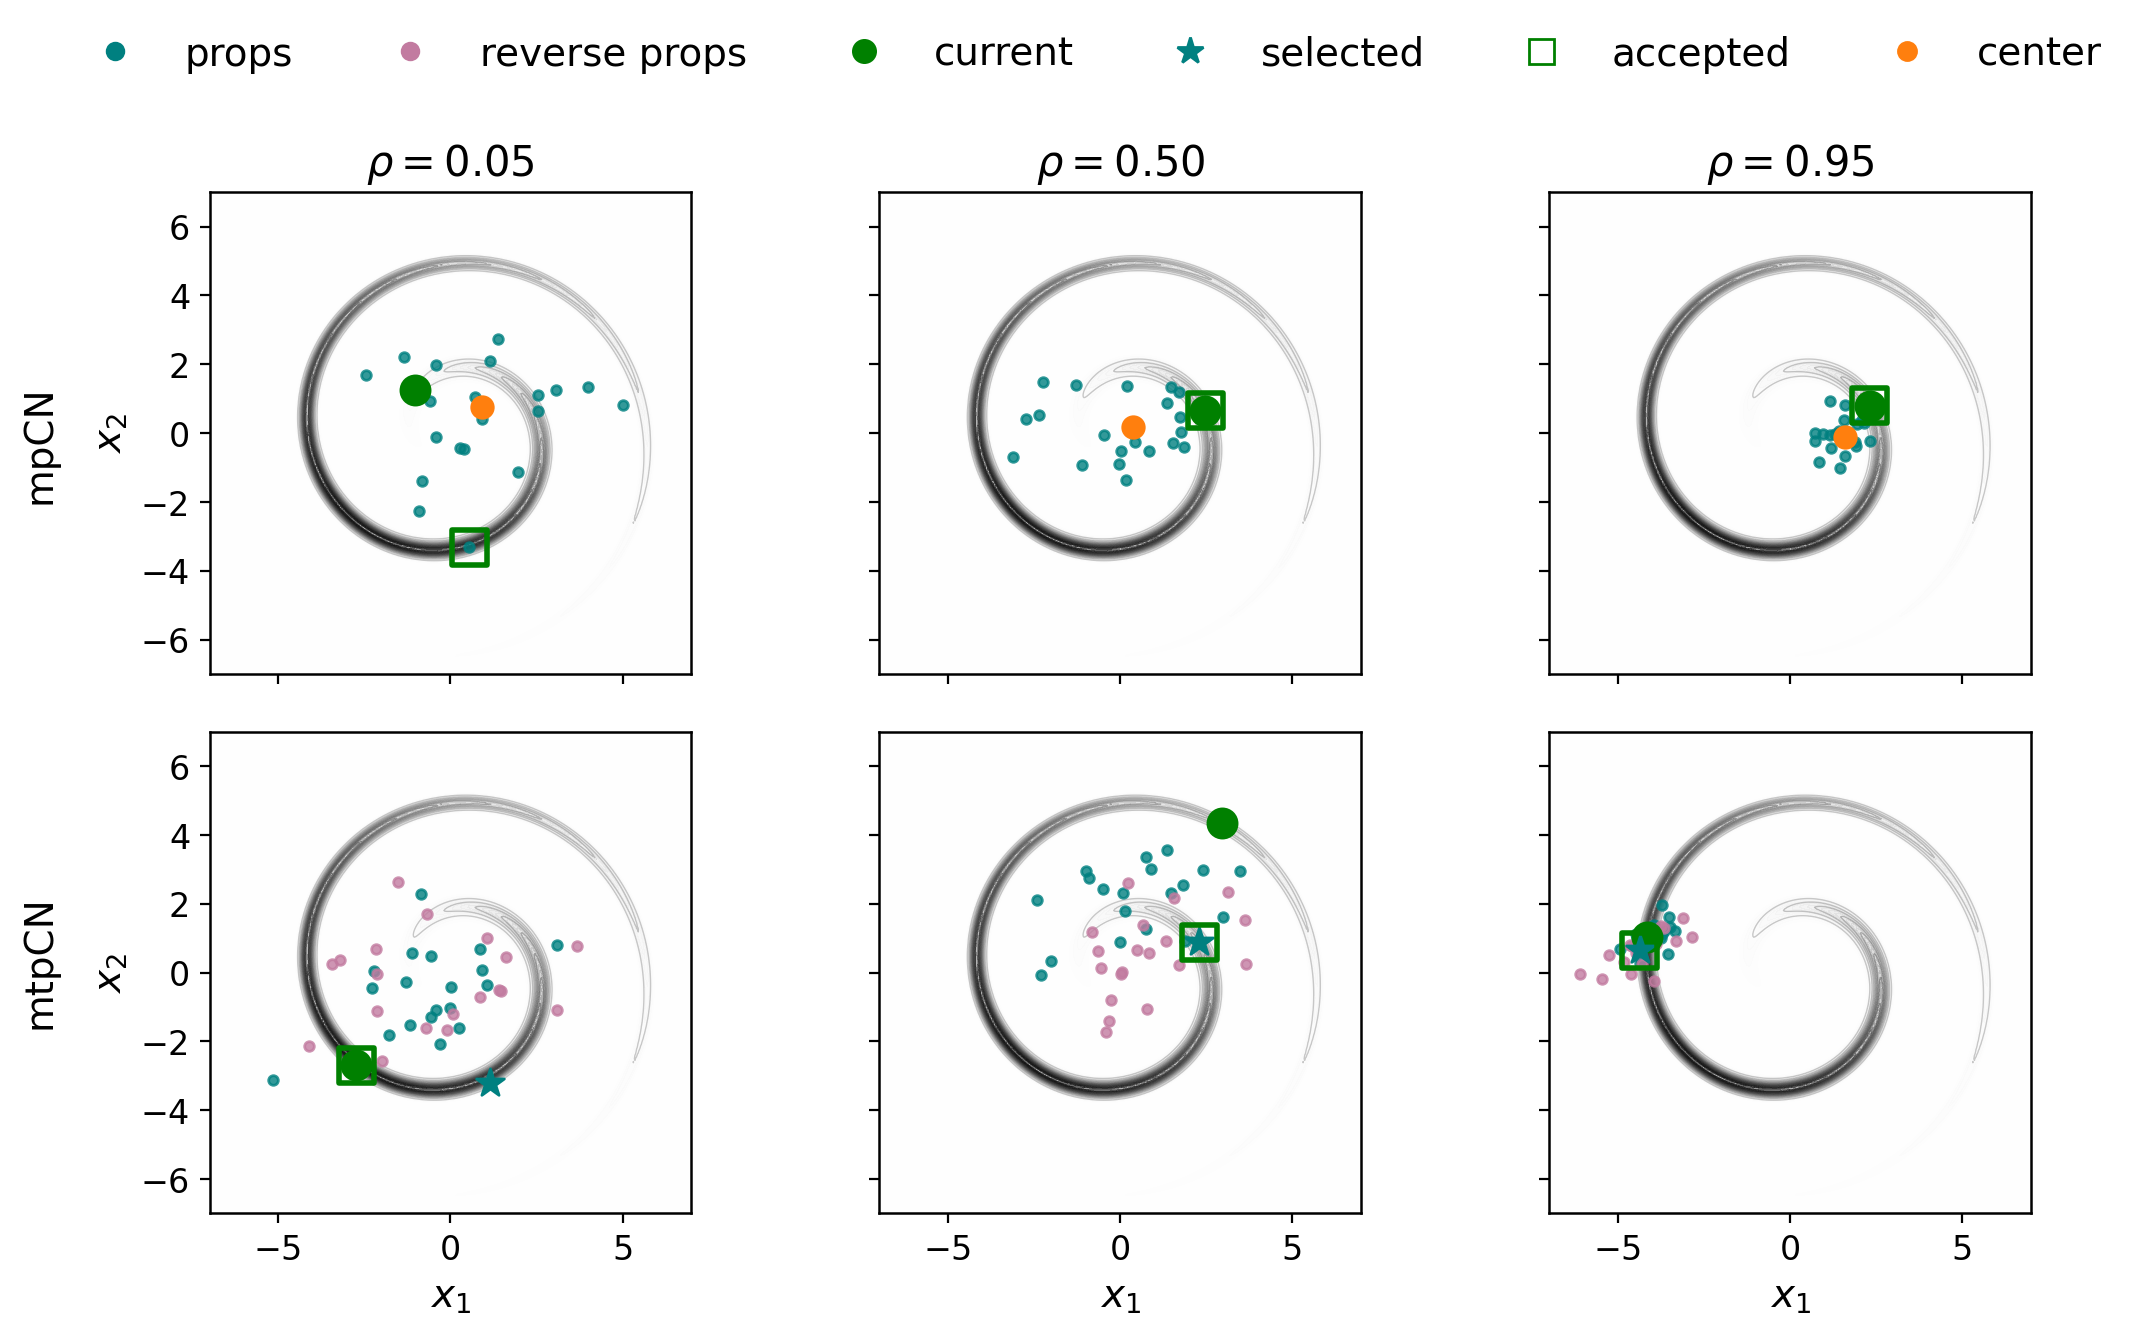

Saved /home/senng/multiproposal-internal/reports/polar_twist/comparisons/polar_twist_comparison_P20_rhos0p05-0p50-0p95_iters200000_seed202_sigma1p00_prior2p00_alpha2p00_wx1p00_wy1p00_hf89a1dde15c3/mpcn_mtpcn_rho_grid_P20_snapshots.png


In [10]:
# Publication-quality rho sweep figure (proposal clouds, mpCN vs mTPCN, P=20)
apply_pub_style()

P_fig = 20
rho_grid = [0.05, 0.5, 0.95]
n_iters_fig = 200000
seed_mcmc_fig = 202

sigma_tag = format_float_tag(sigma_noise, precision=2)
prior_tag = format_float_tag(prior_std, precision=2)
alpha_tag = format_float_tag(alpha, precision=2)
weight_x_tag = format_float_tag(weight_x, precision=2)
weight_y_tag = format_float_tag(weight_y, precision=2)

base_algo_config = {
    "n_iters": n_iters_fig,
    "n_props": P_fig,
    "seed_mcmc": seed_mcmc_fig,
}
sweep_config = {
    "rho_list": rho_grid,
    "P": P_fig,
    "n_iters": n_iters_fig,
    "seed_mcmc": seed_mcmc_fig,
}
comparison_tag_parts = [
    f"P{P_fig}",
    f"rhos{'-'.join(format_float_tag(r, precision=2) for r in rho_grid)}",
    f"iters{n_iters_fig}",
    f"seed{seed_mcmc_fig}",
    f"sigma{sigma_tag}",
    f"prior{prior_tag}",
    f"alpha{alpha_tag}",
    f"wx{weight_x_tag}",
    f"wy{weight_y_tag}",
]
_, comparison_reports_dir, comparison_run_name, comparison_run_config = build_run_dirs(
    repo_root,
    dataset="polar_twist",
    algorithm="comparison",
    data_config=data_config,
    algorithm_config=base_algo_config,
    sweep_config=sweep_config,
    algorithm_dir="comparisons",
    tag_parts=comparison_tag_parts,
 )
comparison_reports_dir.mkdir(parents=True, exist_ok=True)

snapshot_iter = 9010
n_iters_diag = snapshot_iter + 1
theta = np.linspace(0.0, 2.0 * np.pi, 800)

grid_min = -7.0
grid_max = 7.0
grid = np.linspace(grid_min, grid_max, 300)
X1, X2 = np.meshgrid(grid, grid)
log_like = np.zeros_like(X1)
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x_grid = np.array([X1[i, j], X2[i, j]])
        log_like[i, j] = log_likelihood_polar_twist(
            x_grid,
            y_obs,
            sigma=sigma_noise,
            alpha=alpha,
            weight_x=weight_x,
            weight_y=weight_y,
        )
log_like -= log_like.max()
like_density = np.exp(log_like)
levels_fill = 50
levels_line = 14

def snapshot_publication(method, rho_value, iter_idx, seed_offset=0):
    rng_diag = np.random.default_rng(seed_mcmc_fig + seed_offset)
    x = x0.copy()
    props = np.empty((0, 2))
    back_props = np.empty((0, 2))
    current = np.empty((0, 2))
    selected = np.empty((0, 2))
    accepted = np.empty((0, 2))
    centers = np.empty((0, 2))
    for t in range(n_iters_diag):
        if method == "mtpcn":
            x_new, idx, diag = mtpcn_step(
                x,
                problem,
                rng_diag,
                rho=rho_value,
                n_props=P_fig,
                return_idx=True,
                return_diagnostics=True,
                collect_timing=False,
            )
            if t == iter_idx:
                props = diag["props"]
                back_props = diag["back_props"]
                current = x[None, :]
                selected = diag["y_star"][None, :]
                accepted_point = diag["y_star"] if diag["accepted"] else x
                accepted = accepted_point[None, :]
                break
        elif method == "mpcn":
            x_new, idx, diag = mpcn_step(
                x,
                problem,
                rng_diag,
                rho=rho_value,
                n_props=P_fig,
                return_idx=True,
                return_diagnostics=True,
            )
            if t == iter_idx:
                props = diag["props"]
                current = x[None, :]
                centers = diag["x_center"][None, :]
                accepted = diag["candidates"][idx][None, :]
                break
        else:
            raise ValueError(f"Unknown method: {method}")
        x = x_new
    return props, back_props, current, selected, accepted, centers

fig, axes = plt.subplots(2, 3, figsize=(12.5, 7.4), sharex=True, sharey=True, constrained_layout=False)
method_specs = [
    ("mpcn", "mpCN"),
    ("mtpcn", "mTPCN"),
 ]
props_color = "teal"
back_color = "#C27BA0"
current_color = "green"
selected_color = "teal"
center_color = "tab:orange"

for row, (method, label) in enumerate(method_specs):
    for col, rho_value in enumerate(rho_grid):
        ax = axes[row, col]
        ax.contourf(X1, X2, like_density, levels=levels_fill, cmap="Greys", alpha=0.35)
        ax.contour(X1, X2, like_density, levels=levels_line, colors="black", linewidths=0.5, alpha=0.2)
        seed_offset = int(round(rho_value * 1000)) + (0 if method == "mpcn" else 100)
        props, back_props, current, selected, accepted, centers = snapshot_publication(
            method,
            rho_value,
            snapshot_iter,
            seed_offset=seed_offset,
        )
        if props.size:
            ax.scatter(props[:, 0], props[:, 1], color=props_color, s=12, alpha=0.8, zorder=2)
        if back_props.size:
            ax.scatter(back_props[:, 0], back_props[:, 1], color=back_color, s=12, alpha=0.8, zorder=2)
        if current.size:
            ax.scatter(current[:, 0], current[:, 1], color=current_color, s=110, marker="o", zorder=3)
        if selected.size:
            ax.scatter(selected[:, 0], selected[:, 1], color=selected_color, s=110, marker="*", zorder=4)
        if accepted.size:
            ax.scatter(
                accepted[:, 0],
                accepted[:, 1],
                facecolors="none",
                edgecolors=current_color,
                s=160,
                marker="s",
                linewidths=2.0,
                zorder=5,
            )
        if centers.size:
            ax.scatter(centers[:, 0], centers[:, 1], color=center_color, s=60, marker="o", zorder=3)
        ax.set_aspect("equal", adjustable="box")
        if row == 0:
            ax.set_title(rf"$\rho={rho_value:.2f}$")
        if col == 0:
            ax.set_ylabel(rf"$x_2$")
        if row == len(method_specs) - 1:
            ax.set_xlabel(r"$x_1$")

fig.text(0.08, 0.63, "mpCN", rotation=90, va="center", ha="center")
fig.text(0.08, 0.28, "mtpCN", rotation=90, va="center", ha="center")

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker="o", color=props_color, linestyle="None", markersize=6, label="props"),
    Line2D([0], [0], marker="o", color=back_color, linestyle="None", markersize=6, label="reverse props"),
    Line2D([0], [0], marker="o", color=current_color, linestyle="None", markersize=8, label="current"),
    Line2D([0], [0], marker="*", color=selected_color, linestyle="None", markersize=10, label="selected"),
    Line2D([0], [0], marker="s", color=current_color, markerfacecolor="none", linestyle="None", markersize=9, label="accepted"),
    Line2D([0], [0], marker="o", color=center_color, linestyle="None", markersize=6.5, label="center"),
 ]
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 0.93), ncol=6, frameon=False)
# fig.suptitle("Polar twist proposal clouds, P=20", y=1.12)
fig.subplots_adjust(top=0.80, hspace=0.12, wspace=0.12)
fig_path = comparison_reports_dir / f"mpcn_mtpcn_rho_grid_P{P_fig}_snapshots.png"
fig.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Saved {fig_path}")

In [ ]:
# Proposal clouds over 10 iterations (row per method)
apply_pub_style()

snapshot_rho = 0.50
snapshot_iter_start = 9010
snapshot_iter_count = 10
snapshot_iters = list(range(snapshot_iter_start, snapshot_iter_start + snapshot_iter_count))
n_iters_diag = max(snapshot_iters) + 1

if "like_density" not in globals():
    grid_min = -7.0
    grid_max = 7.0
    grid = np.linspace(grid_min, grid_max, 300)
    X1, X2 = np.meshgrid(grid, grid)
    log_like = np.zeros_like(X1)
    for i in range(X1.shape[0]):
        for j in range(X1.shape[1]):
            x_grid = np.array([X1[i, j], X2[i, j]])
            log_like[i, j] = log_likelihood_polar_twist(
                x_grid,
                y_obs,
                sigma=sigma_noise,
                alpha=alpha,
                weight_x=weight_x,
                weight_y=weight_y,
            )
    log_like -= log_like.max()
    like_density = np.exp(log_like)
    levels_fill = 50
    levels_line = 14

def snapshot_publication_multi(method, rho_value, iter_list, seed_offset=0):
    rng_diag = np.random.default_rng(seed_mcmc_fig + seed_offset)
    iter_set = set(iter_list)
    snapshots = {}
    x = x0.copy()
    for t in range(n_iters_diag):
        if method == "mtpcn":
            x_new, idx, diag = mtpcn_step(
                x,
                problem,
                rng_diag,
                rho=rho_value,
                n_props=P_fig,
                return_idx=True,
                return_diagnostics=True,
                collect_timing=False,
            )
            if t in iter_set:
                snapshots[t] = {
                    "props": diag["props"],
                    "back_props": diag["back_props"],
                    "current": x.copy(),
                    "selected": diag["y_star"],
                    "accepted": diag["y_star"] if diag["accepted"] else x.copy(),
                }
        elif method == "mpcn":
            x_new, idx, diag = mpcn_step(
                x,
                problem,
                rng_diag,
                rho=rho_value,
                n_props=P_fig,
                return_idx=True,
                return_diagnostics=True,
            )
            if t in iter_set:
                snapshots[t] = {
                    "props": diag["props"],
                    "current": x.copy(),
                    "center": diag["x_center"],
                    "accepted": diag["candidates"][idx],
                }
        else:
            raise ValueError(f"Unknown method: {method}")
        x = x_new
        if len(snapshots) == len(iter_set):
            break
    return snapshots

props_color = "teal"
back_color = "#C27BA0"
current_color = "green"
selected_color = "teal"
center_color = "tab:orange"

fig, axes = plt.subplots(2, snapshot_iter_count, figsize=(2.2 * snapshot_iter_count, 5.0), sharex=True, sharey=True)
methods = [("mpcn", "mpCN"), ("mtpcn", "mTPCN")]
for row, (method, label) in enumerate(methods):
    seed_offset = int(round(snapshot_rho * 1000)) + (0 if method == "mpcn" else 100)
    snapshots = snapshot_publication_multi(method, snapshot_rho, snapshot_iters, seed_offset=seed_offset)
    for col, iter_idx in enumerate(snapshot_iters):
        ax = axes[row, col]
        ax.contourf(X1, X2, like_density, levels=levels_fill, cmap="Greys", alpha=0.35)
        ax.contour(X1, X2, like_density, levels=levels_line, colors="black", linewidths=0.5, alpha=0.2)
        snap = snapshots.get(iter_idx, None)
        if snap is not None:
            ax.scatter(snap["props"][:, 0], snap["props"][:, 1], color=props_color, s=12, alpha=0.8, zorder=2)
            if method == "mtpcn":
                ax.scatter(snap["back_props"][:, 0], snap["back_props"][:, 1], color=back_color, s=12, alpha=0.8, zorder=2)
                ax.scatter([snap["selected"][0]], [snap["selected"][1]], color=selected_color, s=110, marker="*", zorder=4)
            else:
                ax.scatter([snap["center"][0]], [snap["center"][1]], color=center_color, s=80, marker="o", zorder=3)
            ax.scatter([snap["current"][0]], [snap["current"][1]], color=current_color, s=110, marker="o", zorder=3)
            ax.scatter(
                [snap["accepted"][0]],
                [snap["accepted"][1]],
                facecolors="none",
                edgecolors=current_color,
                s=160,
                marker="s",
                linewidths=2.0,
                zorder=5,
            )
            label_idx = iter_idx - snapshot_iter_start + 1
            ax.text(
                snap["current"][0] + 0.15,
                snap["current"][1] + 0.15,
                f"{label_idx}",
                color="black",
                fontsize=7,
                ha="left",
                va="bottom",
                zorder=6,
            )
        ax.set_aspect("equal", adjustable="box")
        if row == 0:
            ax.set_title(rf"$i={iter_idx}$", fontsize=10)
        if col == 0:
            ax.set_ylabel(rf"{label}\n$x_2$")
        if row == len(methods) - 1:
            ax.set_xlabel(r"$x_1$")

from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker="o", color=props_color, linestyle="None", markersize=6, label="props"),
    Line2D([0], [0], marker="o", color=back_color, linestyle="None", markersize=6, label="reverse props"),
    Line2D([0], [0], marker="o", color=current_color, linestyle="None", markersize=8, label="current"),
    Line2D([0], [0], marker="*", color=selected_color, linestyle="None", markersize=10, label="selected"),
    Line2D([0], [0], marker="s", color=current_color, markerfacecolor="none", linestyle="None", markersize=9, label="accepted"),
    Line2D([0], [0], marker="o", color=center_color, linestyle="None", markersize=7, label="center"),
 ]
fig.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, 1.06), ncol=6, frameon=False)
fig.suptitle(rf"Polar twist proposal clouds, $\rho={snapshot_rho:.2f}$", y=1.12)
fig.subplots_adjust(top=0.80, hspace=0.12, wspace=0.12)
fig_path = comparison_reports_dir / f"mpcn_mtpcn_rho{format_float_tag(snapshot_rho, precision=2)}_iterrow.png"
fig.savefig(fig_path, bbox_inches="tight")
plt.show()
print(f"Saved {fig_path}")